In [ ]:
#  Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#  Clean data 
data = pd.read_csv('../data/clean_data.csv')
data.head()

,link,headline,category,short_description,authors,date,full_text,clean_text
0,https://www.huffingtonpost.com/entry/what-if-w...,What If We Were All Family Generation Changers?,IMPACT,"What if, in doing so, we won't just create new...","Matt Murrie, ContributorEdupreneur, Cofounder/...",2014-06-20,What If We Were All Family Generation Changers...,family generation changer wont create new oppo...
1,https://www.huffingtonpost.comhttp://www.washi...,Firestorm At AOL Over Employee Benefit Cuts,BUSINESS,It should have been a glorious week for AOL ch...,NaN,2014-02-08,Firestorm At AOL Over Employee Benefit Cuts It...,firestorm aol employee benefit cut glorious we...
2,https://www.huffingtonpost.com/entry/time-runs...,Dakota Access Protesters Arrested As Deadline ...,POLITICS,A few protesters who refused to leave remained...,"Michael McLaughlin & Josh Morgan, The Huffingt...",2017-02-22,Dakota Access Protesters Arrested As Deadline ...,dakota access protester arrested deadline pass...
3,https://www.huffingtonpost.com/entry/one-glimp...,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,NaN,NaN,2014-05-14,One Glimpse Of These Baby Kit Foxes And You'll...,one glimpse baby kit fox youll hooked
4,https://www.huffingtonpost.com/entry/mens-swea...,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,Scientists didn't know if humans played that g...,Melissa Cronin,2013-06-02,"Mens' Sweat Pheromone, Androstadienone, Influe...",men sweat pheromone androstadienone influence ...


In [ ]:
data.shape

(10000, 8)

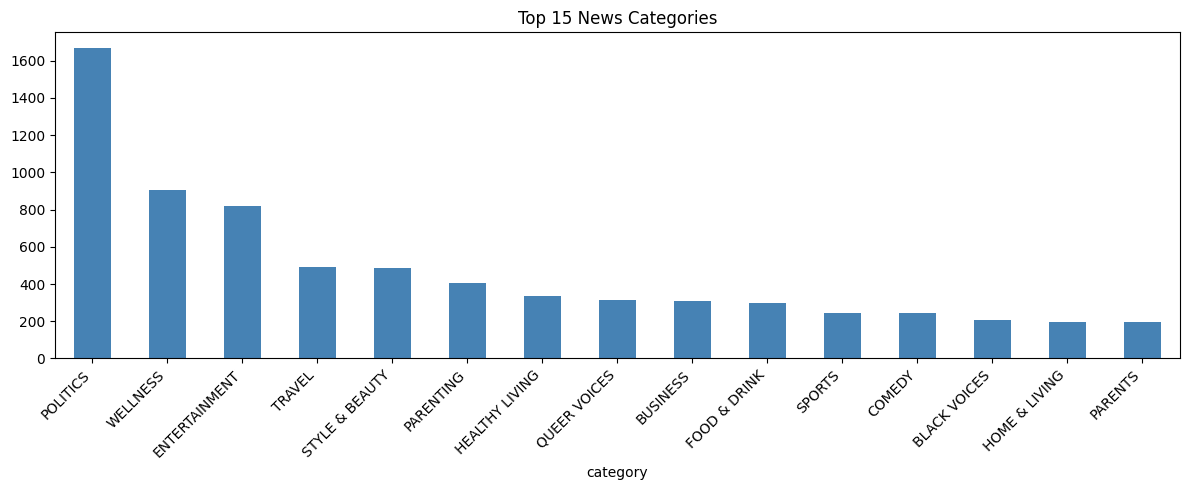

In [6]:
plt.figure(figsize=(12, 5))
data['category'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 News Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../graphs/eda1_categories.png')
plt.show()

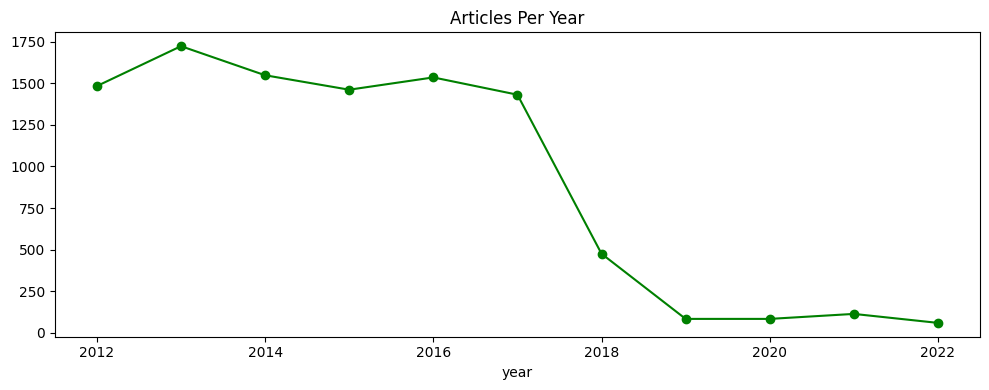

In [7]:
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year

plt.figure(figsize=(10, 4))
data['year'].value_counts().sort_index().plot(kind='line', marker='o', color='green')
plt.title('Articles Per Year')
plt.tight_layout()
plt.savefig('../graphs/eda2_yearly.png')
plt.show()

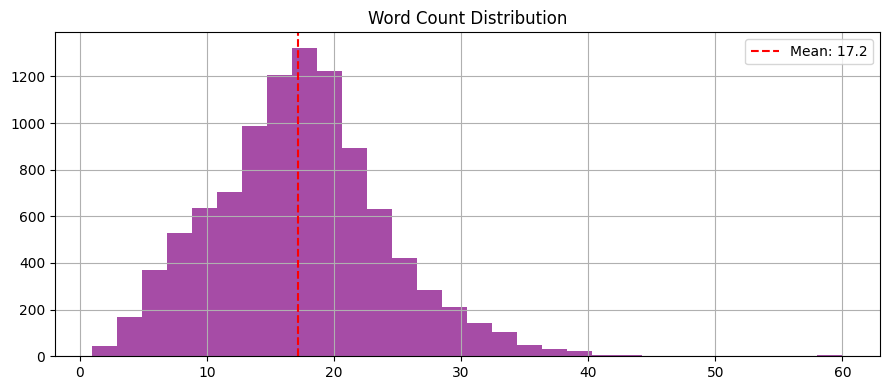

In [8]:
data['word_count'] = data['clean_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 4))
data['word_count'].clip(0, 60).hist(bins=30, color='purple', alpha=0.7)
plt.axvline(data['word_count'].mean(), color='red', linestyle='--',
            label=f"Mean: {data['word_count'].mean():.1f}")
plt.title('Word Count Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../graphs/eda3_wordcount.png')
plt.show()

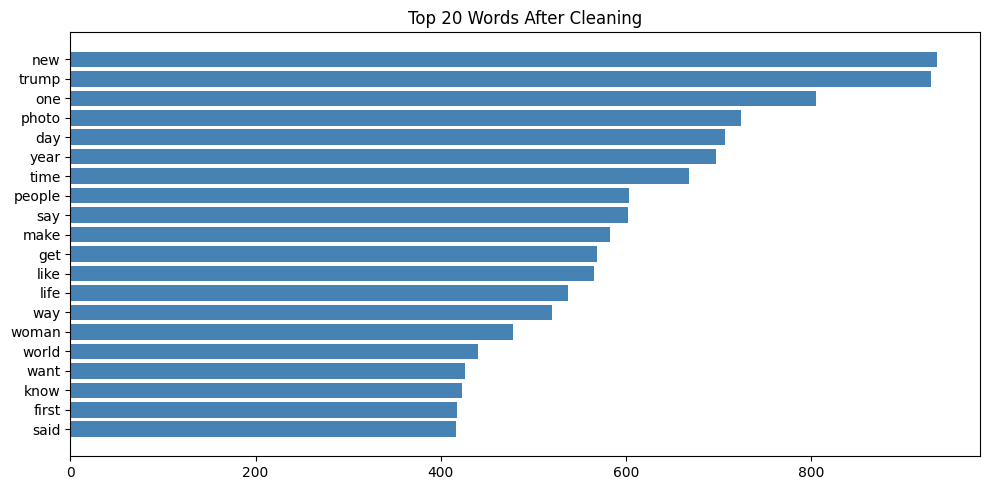

In [9]:
from collections import Counter

all_words = ' '.join(data['clean_text'].dropna()).split()
top_words = Counter(all_words).most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.title('Top 20 Words After Cleaning')
plt.tight_layout()
plt.savefig('../graphs/eda4_topwords.png')
plt.show()